# 일봉차트 만들기

### Data processing

In [1]:
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt
import time

In [2]:
from TickerDict import tickers

In [3]:
import DayChart

In [4]:
from pykiwoom.kiwoom import *
kiwoom = Kiwoom()

In [5]:
kiwoom.CommConnect(block=True)
print("블록킹 로그인 완료")

블록킹 로그인 완료


In [6]:
sss = DayChart.StockDataProcessor(kiwoom)

In [7]:
sss.get_stock_code('현대힘스',tickers)

'460930'

In [8]:
df = sss.fetch_stock_data('460930','20250122')

{'trcode': 'opt10086', 'input': [{'일별주가요청': ['종목코드', '조회일자', '표시구분']}], 'output': [{'일별주가': ['날짜', '시가', '고가', '저가', '종가', '전일비', '등락률', '거래량', '금액(백만)', '신용비', '개인', '기관', '외인수량', '외국계', '프로그램', '외인비', '외인보유', '외인비중', '외인순매수', '기관순매수', '개인순매수', '신용잔고율']}]}
{'trcode': 'opt10086', 'input': [{'일별주가요청': ['종목코드', '조회일자', '표시구분']}], 'output': [{'일별주가': ['날짜', '시가', '고가', '저가', '종가', '전일비', '등락률', '거래량', '금액(백만)', '신용비', '개인', '기관', '외인수량', '외국계', '프로그램', '외인비', '외인보유', '외인비중', '외인순매수', '기관순매수', '개인순매수', '신용잔고율']}]}


In [9]:
df = sss.preprocess_data(df)

In [10]:
df  = sss.add_moving_averages(df)

In [11]:
df

,Open,High,Low,Close,Change,ChangeRate,Volume,TradingValue,Program,ForeignNetBuy,InstitutionNetBuy,IndividualNetBuy,10DMA,20DMA
datetime,,,,,,,,,,,,,,
2024-11-25,14450,15140,14440,15140,690,4.78,604728,8951,-86,-5892,34,52,NaN,NaN
2024-11-26,15140,15190,14730,15190,50,0.33,404804,6054,-398,-26520,-22,397,NaN,NaN
2024-11-27,15040,15500,14330,14440,-750,-4.94,678688,10188,-524,-34227,-31,548,NaN,NaN
2024-11-28,14310,15890,14140,14630,190,1.32,2332620,35637,343,19242,1,-271,NaN,NaN
2024-11-29,14630,14840,14220,14310,-320,-2.19,343664,4947,-376,-25924,-1,311,NaN,NaN
2024-12-02,14370,14640,13260,13330,-980,-6.85,499515,6863,61,-1931,2,8,NaN,NaN
2024-12-03,13210,13810,13200,13710,380,2.85,309442,4192,749,55426,0,-782,NaN,NaN
2024-12-04,13170,13480,12780,13000,-710,-5.18,516062,6729,620,47933,-1,-771,NaN,NaN
2024-12-05,12900,13040,12360,12670,-330,-2.54,271911,3434,803,63689,0,-820,NaN,NaN


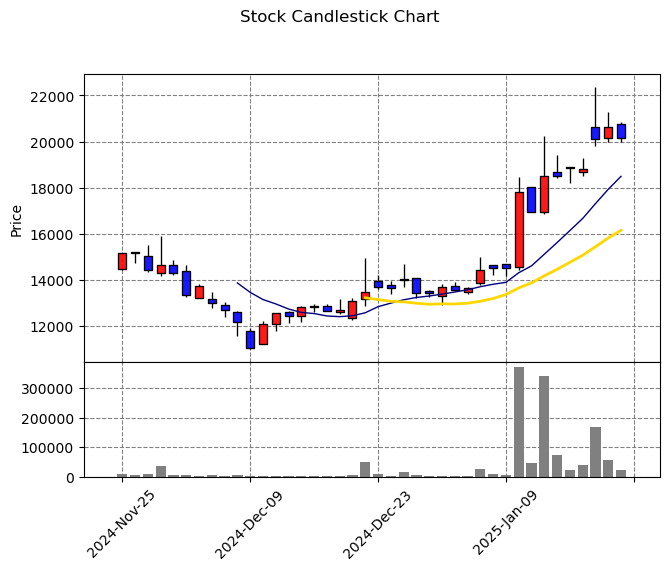

In [12]:
sss3 = sss.plot_candlestick(df)

In [58]:
# Import the dictionary from TickerDict.py

from TickerDict import tickers  # Correctly imports the tickers variable

 # Use tickers
종목명 = input("Enter 종목명(e.g., 삼성전자): ")
date = input("Enter 기준일자 (e.g., 20250119): ")
if 종목명 in tickers:
    code = tickers[종목명]
    print(f"종목명: {종목명}, 종목코드: {tickers[종목명]}")
else:
    print(f"종목명 '{종목명}' not found.")

Enter 종목명(e.g., 삼성전자):  삼성전자
Enter 기준일자 (e.g., 20250119):  20250119


종목명: 삼성전자, 종목코드: 005930


In [10]:
code

'460930'

In [11]:
df = kiwoom.block_request("opt10086",
                          종목코드=code,
                          기준일자=date,
                          표시구분=1,
                          output="일별주가요청",
                          next=1)
df

{'trcode': 'opt10086', 'input': [{'일별주가요청': ['종목코드', '조회일자', '표시구분']}], 'output': [{'일별주가': ['날짜', '시가', '고가', '저가', '종가', '전일비', '등락률', '거래량', '금액(백만)', '신용비', '개인', '기관', '외인수량', '외국계', '프로그램', '외인비', '외인보유', '외인비중', '외인순매수', '기관순매수', '개인순매수', '신용잔고율']}]}


,날짜,시가,고가,저가,종가,전일비,등락률,거래량,금액(백만),신용비,...,외인수량,외국계,프로그램,외인비,외인보유,외인비중,외인순매수,기관순매수,개인순매수,신용잔고율
0,20250122,+20750,+20850,-20000,-20150,-500,-2.42,1149573,23445,0.00,...,0,--45,--492,+0.38,+0.38,+0.38,0,--4,+520,0.00
1,20250121,+20150,+21300,-19960,+20650,+550,+2.74,2750952,56768,2.67,...,+26086,+198,+503,+0.38,+0.38,+0.38,+26086,--15,--514,2.67
2,20250120,+20650,+22350,+19820,+20100,+1290,+6.86,7974403,168408,2.76,...,+24751,+335,+386,+0.31,+0.31,+0.31,+24751,--65,--205,2.76
3,20250117,-18660,+19300,-18510,-18810,-90,-0.48,2034230,38974,2.61,...,+7424,+29,+131,+0.24,+0.24,+0.24,+7424,+79,--9,2.61
4,20250116,+18860,+18900,-18200,+18900,+410,+2.22,1255764,23310,2.44,...,--6900,--18,--145,+0.22,+0.22,+0.22,--6900,+13,+153,2.44
5,20250115,+18670,+19430,-18400,18490,0,0.00,3884488,73462,2.47,...,--105437,--1819,--2126,+0.24,+0.24,+0.24,--105437,--20,+1725,2.47
6,20250114,-16940,+20250,-16850,+18490,+1530,+9.02,17955440,341744,2.14,...,+109466,+1991,+1893,+0.54,+0.54,+0.54,+109466,+13,--1750,2.14
7,20250113,+18020,+18020,-16960,-16960,-840,-4.72,2785962,48440,1.46,...,--126328,--2135,--2280,+0.23,+0.23,+0.23,--126328,--6,+2276,1.46
8,20250110,+14560,+18450,-14420,+17800,+3280,+22.59,21280011,370661,1.53,...,+120867,+2062,+2070,+0.58,+0.58,+0.58,+120867,--1,--1995,1.53
9,20250109,+14700,+14700,-14150,14520,0,0.00,328253,4729,1.52,...,+1536,+79,+21,+0.24,+0.24,+0.24,+1536,+1,--12,1.52


In [12]:

dfs = []
df = kiwoom.block_request("opt10086",
                          종목코드=code,
                          기준일자=date,
                          표시구분=1,
                          output="일별주가요청",
                          next=1)

dfs.append(df)
a=0
while a<2:
    a = a+1
    df = kiwoom.block_request("opt10086",
                          종목코드=code,
                          기준일자=date,
                          표시구분=1,
                          output="일별주가요청",
                          next=2)
    dfs.append(df)
    time.sleep(1)
    
df = pd.concat(dfs, ignore_index=True)


{'trcode': 'opt10086', 'input': [{'일별주가요청': ['종목코드', '조회일자', '표시구분']}], 'output': [{'일별주가': ['날짜', '시가', '고가', '저가', '종가', '전일비', '등락률', '거래량', '금액(백만)', '신용비', '개인', '기관', '외인수량', '외국계', '프로그램', '외인비', '외인보유', '외인비중', '외인순매수', '기관순매수', '개인순매수', '신용잔고율']}]}
{'trcode': 'opt10086', 'input': [{'일별주가요청': ['종목코드', '조회일자', '표시구분']}], 'output': [{'일별주가': ['날짜', '시가', '고가', '저가', '종가', '전일비', '등락률', '거래량', '금액(백만)', '신용비', '개인', '기관', '외인수량', '외국계', '프로그램', '외인비', '외인보유', '외인비중', '외인순매수', '기관순매수', '개인순매수', '신용잔고율']}]}
{'trcode': 'opt10086', 'input': [{'일별주가요청': ['종목코드', '조회일자', '표시구분']}], 'output': [{'일별주가': ['날짜', '시가', '고가', '저가', '종가', '전일비', '등락률', '거래량', '금액(백만)', '신용비', '개인', '기관', '외인수량', '외국계', '프로그램', '외인비', '외인보유', '외인비중', '외인순매수', '기관순매수', '개인순매수', '신용잔고율']}]}


In [14]:
df = df.drop(columns=["신용비", "개인", "기관", "외인수량", "외국계", "외인비", "외인보유", "외인비중", "신용잔고율"])

In [13]:
df.dtypes

날짜        object
시가        object
고가        object
저가        object
종가        object
전일비       object
등락률       object
거래량       object
금액(백만)    object
신용비       object
개인        object
기관        object
외인수량      object
외국계       object
프로그램      object
외인비       object
외인보유      object
외인비중      object
외인순매수     object
기관순매수     object
개인순매수     object
신용잔고율     object
dtype: object

In [15]:
df.dtypes

날짜        object
시가        object
고가        object
저가        object
종가        object
전일비       object
등락률       object
거래량       object
금액(백만)    object
프로그램      object
외인순매수     object
기관순매수     object
개인순매수     object
dtype: object

In [16]:
df.head()

,날짜,시가,고가,저가,종가,전일비,등락률,거래량,금액(백만),프로그램,외인순매수,기관순매수,개인순매수
0,20250122,+20750,+20850,-20000,-20150,-500,-2.42,1149573,23445,--492,0,--4,+520
1,20250121,+20150,+21300,-19960,+20650,+550,+2.74,2750952,56768,+503,+26086,--15,--514
2,20250120,+20650,+22350,+19820,+20100,+1290,+6.86,7974403,168408,+386,+24751,--65,--205
3,20250117,-18660,+19300,-18510,-18810,-90,-0.48,2034230,38974,+131,+7424,+79,--9
4,20250116,+18860,+18900,-18200,+18900,+410,+2.22,1255764,23310,--145,--6900,+13,+153


In [17]:
columns_to_replace = ['프로그램','외인순매수','기관순매수','개인순매수']
df[columns_to_replace] = df[columns_to_replace].replace("--", "-", regex=True)
df.head()

,날짜,시가,고가,저가,종가,전일비,등락률,거래량,금액(백만),프로그램,외인순매수,기관순매수,개인순매수
0,20250122,+20750,+20850,-20000,-20150,-500,-2.42,1149573,23445,-492,0,-4,+520
1,20250121,+20150,+21300,-19960,+20650,+550,+2.74,2750952,56768,+503,+26086,-15,-514
2,20250120,+20650,+22350,+19820,+20100,+1290,+6.86,7974403,168408,+386,+24751,-65,-205
3,20250117,-18660,+19300,-18510,-18810,-90,-0.48,2034230,38974,+131,+7424,+79,-9
4,20250116,+18860,+18900,-18200,+18900,+410,+2.22,1255764,23310,-145,-6900,+13,+153


In [18]:
df.dtypes

날짜        object
시가        object
고가        object
저가        object
종가        object
전일비       object
등락률       object
거래량       object
금액(백만)    object
프로그램      object
외인순매수     object
기관순매수     object
개인순매수     object
dtype: object

In [19]:
# Change the data type of '날짜' to datetime
df["날짜"] = pd.to_datetime(df["날짜"], format="%Y%m%d")

# Change the data type of '등락률' to float
df["등락률"] = df["등락률"].astype(float)

# Change all other columns to int
columns_to_convert = df.columns.difference(["날짜", "등락률"])
df[columns_to_convert] = df[columns_to_convert].astype(int)

In [20]:
# Divide the values in the "금액" column by 100
df["금액(백만)"] = df["금액(백만)"] / 100
# Rename the "금액" column to "금액(억)"
df.rename(columns={"금액(백만)": "금액(억)"}, inplace=True)

In [21]:
df.dtypes

날짜       datetime64[ns]
시가                int32
고가                int32
저가                int32
종가                int32
전일비               int32
등락률             float64
거래량               int32
금액(억)           float64
프로그램              int32
외인순매수             int32
기관순매수             int32
개인순매수             int32
dtype: object

In [22]:
df

,날짜,시가,고가,저가,종가,전일비,등락률,거래량,금액(억),프로그램,외인순매수,기관순매수,개인순매수
0,2025-01-22,20750,20850,-20000,-20150,-500,-2.42,1149573,234.45,-492,0,-4,520
1,2025-01-21,20150,21300,-19960,20650,550,2.74,2750952,567.68,503,26086,-15,-514
2,2025-01-20,20650,22350,19820,20100,1290,6.86,7974403,1684.08,386,24751,-65,-205
3,2025-01-17,-18660,19300,-18510,-18810,-90,-0.48,2034230,389.74,131,7424,79,-9
4,2025-01-16,18860,18900,-18200,18900,410,2.22,1255764,233.10,-145,-6900,13,153
5,2025-01-15,18670,19430,-18400,18490,0,0.00,3884488,734.62,-2126,-105437,-20,1725
6,2025-01-14,-16940,20250,-16850,18490,1530,9.02,17955440,3417.44,1893,109466,13,-1750
7,2025-01-13,18020,18020,-16960,-16960,-840,-4.72,2785962,484.40,-2280,-126328,-6,2276
8,2025-01-10,14560,18450,-14420,17800,3280,22.59,21280011,3706.61,2070,120867,-1,-1995
9,2025-01-09,14700,14700,-14150,14520,0,0.00,328253,47.29,21,1536,1,-12


In [23]:
df = df.iloc[::-1].reset_index(drop=True)
df

,날짜,시가,고가,저가,종가,전일비,등락률,거래량,금액(억),프로그램,외인순매수,기관순매수,개인순매수
0,2024-10-28,-9780,9920,-9750,9900,60,0.61,77522,7.64,388,39339,1,-397
1,2024-10-29,9920,10120,-9850,10090,190,1.92,68913,6.86,136,13675,-40,-88
2,2024-10-30,-9990,10120,-9890,-9940,-150,-1.49,54434,5.42,-56,-5616,-41,84
3,2024-10-31,-9930,9990,-9580,9960,20,0.20,89128,8.72,180,18219,0,-181
4,2024-11-01,9980,9980,-9710,-9860,-100,-1.00,58121,5.69,-21,-2228,-67,88
5,2024-11-04,-9810,10190,-9810,10110,250,2.54,64024,6.45,337,33250,-44,-292
6,2024-11-05,10110,10400,-10090,10180,70,0.69,70393,7.23,203,19807,0,-206
7,2024-11-06,10180,10310,-10000,10300,120,1.18,66953,6.81,209,20615,0,-209
8,2024-11-07,10360,13390,-10280,13390,3090,30.00,5053687,654.55,-2080,-162504,267,1578
9,2024-11-08,15310,15700,14270,14610,1220,9.11,10252610,1534.99,-137,3624,-736,1036


### mplfinance library

In [24]:
df.dtypes

날짜       datetime64[ns]
시가                int32
고가                int32
저가                int32
종가                int32
전일비               int32
등락률             float64
거래량               int32
금액(억)           float64
프로그램              int32
외인순매수             int32
기관순매수             int32
개인순매수             int32
dtype: object

In [25]:
# Rename columns
df = df.rename(columns={
    "날짜": "datetime",
    "시가": "Open",
    "고가": "High",
    "저가": "Low",
    "종가": "Close",
    "거래량": "Volume",       # Optional if volume is available
    "전일비": "Change",       # Change compared to the previous day
    "등락률": "ChangeRate",   # Change rate (percentage)
    "금액(억)": "TradingValue", # Trading value
    "프로그램": "Program",    # Program trading
    "외인순매수": "ForeignNetBuy", # Foreign net buy
    "기관순매수": "InstitutionNetBuy", # Institution net buy
    "개인순매수": "IndividualNetBuy"  # Individual net buy
})

# Check the DataFrame to ensure the columns are renamed correctly



In [26]:
df.head()

,datetime,Open,High,Low,Close,Change,ChangeRate,Volume,TradingValue,Program,ForeignNetBuy,InstitutionNetBuy,IndividualNetBuy
0,2024-10-28,-9780,9920,-9750,9900,60,0.61,77522,7.64,388,39339,1,-397
1,2024-10-29,9920,10120,-9850,10090,190,1.92,68913,6.86,136,13675,-40,-88
2,2024-10-30,-9990,10120,-9890,-9940,-150,-1.49,54434,5.42,-56,-5616,-41,84
3,2024-10-31,-9930,9990,-9580,9960,20,0.20,89128,8.72,180,18219,0,-181
4,2024-11-01,9980,9980,-9710,-9860,-100,-1.00,58121,5.69,-21,-2228,-67,88


In [27]:
# DataFrame의 인덱스를 날짜로 설정 (mplfinance가 요구하는 포맷)
df.set_index("datetime", inplace=True)

In [28]:
df.head()

,Open,High,Low,Close,Change,ChangeRate,Volume,TradingValue,Program,ForeignNetBuy,InstitutionNetBuy,IndividualNetBuy
datetime,,,,,,,,,,,,
2024-10-28,-9780,9920,-9750,9900,60,0.61,77522,7.64,388,39339,1,-397
2024-10-29,9920,10120,-9850,10090,190,1.92,68913,6.86,136,13675,-40,-88
2024-10-30,-9990,10120,-9890,-9940,-150,-1.49,54434,5.42,-56,-5616,-41,84
2024-10-31,-9930,9990,-9580,9960,20,0.20,89128,8.72,180,18219,0,-181
2024-11-01,9980,9980,-9710,-9860,-100,-1.00,58121,5.69,-21,-2228,-67,88


In [29]:
# Apply absolute value transformation to specific columns
columns_to_transform = ["Open", "High", "Low", "Close"]
df[columns_to_transform] = df[columns_to_transform].abs()

In [30]:
df.head()

,Open,High,Low,Close,Change,ChangeRate,Volume,TradingValue,Program,ForeignNetBuy,InstitutionNetBuy,IndividualNetBuy
datetime,,,,,,,,,,,,
2024-10-28,9780,9920,9750,9900,60,0.61,77522,7.64,388,39339,1,-397
2024-10-29,9920,10120,9850,10090,190,1.92,68913,6.86,136,13675,-40,-88
2024-10-30,9990,10120,9890,9940,-150,-1.49,54434,5.42,-56,-5616,-41,84
2024-10-31,9930,9990,9580,9960,20,0.20,89128,8.72,180,18219,0,-181
2024-11-01,9980,9980,9710,9860,-100,-1.00,58121,5.69,-21,-2228,-67,88


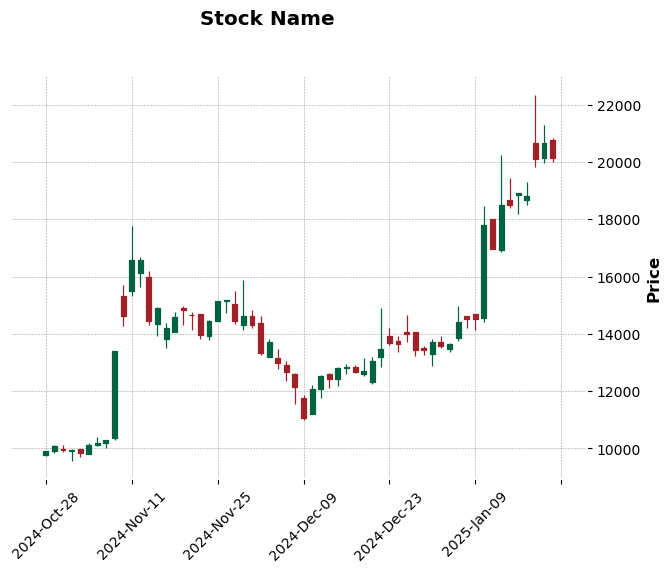

In [31]:
# 2. 봉차트 그리기
mpf.plot(
    df,
    type="candle",  # 봉차트
    style="charles",  # 스타일 (다양한 스타일 지원)
    title="Stock Name",  # 차트 제목
    ylabel="Price",  # y축 라벨
    volume=False  # 거래량 표시 여부 (False로 설정)
)

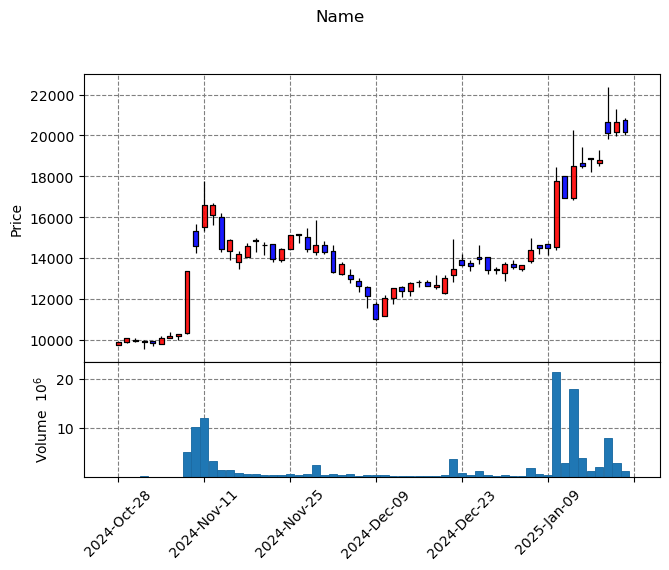

In [32]:
# Custom market colors
custom_colors = mpf.make_marketcolors(
    up="red",    # Custom color for up (e.g., blue)
    down="blue", # Custom color for down (e.g., orange)
    wick="black",  # Wick color
    edge="black"   # Edge color
)

# Custom style with the market colors
custom_style = mpf.make_mpf_style(
    marketcolors=custom_colors, 
    gridcolor="gray",  # Gridline color
    gridstyle="--"     # Gridline style
)


mpf.plot(
    df,
    type="candle",
    style=custom_style,
    title="Name",
    ylabel="Price",
    volume=True  
)


In [33]:
df.head()

,Open,High,Low,Close,Change,ChangeRate,Volume,TradingValue,Program,ForeignNetBuy,InstitutionNetBuy,IndividualNetBuy
datetime,,,,,,,,,,,,
2024-10-28,9780,9920,9750,9900,60,0.61,77522,7.64,388,39339,1,-397
2024-10-29,9920,10120,9850,10090,190,1.92,68913,6.86,136,13675,-40,-88
2024-10-30,9990,10120,9890,9940,-150,-1.49,54434,5.42,-56,-5616,-41,84
2024-10-31,9930,9990,9580,9960,20,0.20,89128,8.72,180,18219,0,-181
2024-11-01,9980,9980,9710,9860,-100,-1.00,58121,5.69,-21,-2228,-67,88


In [34]:
df['10DMA']=df['Close'].rolling(window=10).mean()
df['20DMA']=df['Close'].rolling(window=20).mean()
df['10DMA']

datetime
2024-10-28        NaN
2024-10-29        NaN
2024-10-30        NaN
2024-10-31        NaN
2024-11-01        NaN
2024-11-04        NaN
2024-11-05        NaN
2024-11-06        NaN
2024-11-07        NaN
2024-11-08    10834.0
2024-11-11    11502.0
2024-11-12    12152.0
2024-11-13    12603.0
2024-11-14    13097.0
2024-11-15    13531.0
2024-11-18    13980.0
2024-11-19    14447.0
2024-11-20    14882.0
2024-11-21    14940.0
2024-11-22    14924.0
2024-11-25    14780.0
2024-11-26    14640.0
2024-11-27    14639.0
2024-11-28    14612.0
2024-11-29    14623.0
2024-12-02    14496.0
2024-12-03    14382.0
2024-12-04    14217.0
2024-12-05    14087.0
2024-12-06    13858.0
2024-12-09    13449.0
2024-12-10    13138.0
2024-12-11    12948.0
2024-12-12    12727.0
2024-12-13    12576.0
2024-12-16    12529.0
2024-12-17    12424.0
2024-12-18    12394.0
2024-12-19    12433.0
2024-12-20    12563.0
2024-12-23    12827.0
2024-12-24    12982.0
2024-12-26    13126.0
2024-12-27    13227.0
2024-12-30    13290.0
2

In [35]:
# Calculate 10-day and 20-day moving averages
df["10DMA"] = df["Close"].rolling(window=10).mean()
df["20DMA"] = df["Close"].rolling(window=20).mean()

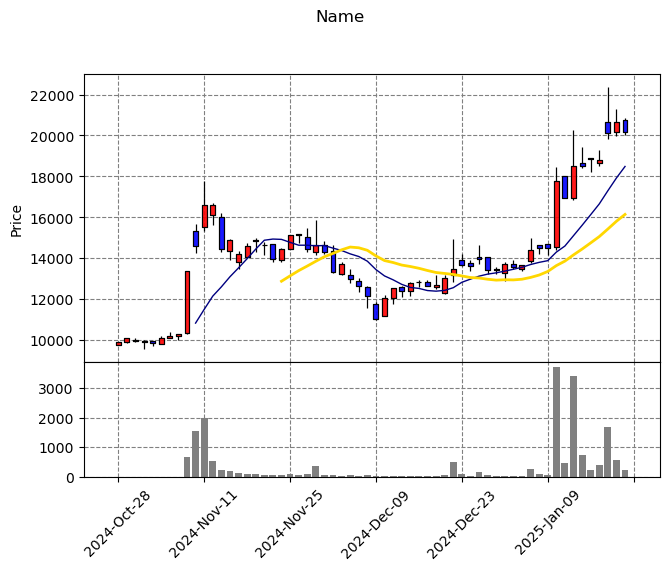

In [36]:
# Custom market colors
custom_colors = mpf.make_marketcolors(
    up="red",    # Custom color for up (e.g., blue)
    down="blue", # Custom color for down (e.g., orange)
    wick="black",  # Wick color
    edge="black"   # Edge color
)

# Custom style with the market colors
custom_style = mpf.make_mpf_style(
    marketcolors=custom_colors, 
    gridcolor="gray",  # Gridline color
    gridstyle="--"     # Gridline style
)

# Define the additional plots for the moving averages
add_plots = [
    mpf.make_addplot(df["10DMA"], color="navy", width=1.0, linestyle="solid"),
    mpf.make_addplot(df["20DMA"], color="gold", width=2.0, linestyle="solid"),
    mpf.make_addplot(df["TradingValue"], panel=1, color="gray", type="bar")
]


mpf.plot(
    df,
    type="candle",
    style=custom_style,
    title="Name",
    ylabel="Price",
    ylabel_lower="Trading Value",
    volume=False,
    addplot=add_plots,
)



In [37]:
import sys

# Print the list of paths
for path in sys.path:
    print(path)


C:\anaconda3\envs\py39_32\python39.zip
C:\anaconda3\envs\py39_32\DLLs
C:\anaconda3\envs\py39_32\lib
C:\anaconda3\envs\py39_32

C:\anaconda3\envs\py39_32\lib\site-packages
C:\anaconda3\envs\py39_32\lib\site-packages\locket-0.2.1-py3.9.egg
C:\anaconda3\envs\py39_32\lib\site-packages\win32
C:\anaconda3\envs\py39_32\lib\site-packages\win32\lib
C:\anaconda3\envs\py39_32\lib\site-packages\Pythonwin


### TickerDict.py generation {stock name: stock code}

In [38]:
# Get tickers for KOSPI and KOSDAQ
kospi_tickers = kiwoom.GetCodeListByMarket("0")  # KOSPI
kosdaq_tickers = kiwoom.GetCodeListByMarket("10")  # KOSDAQ

# Create dictionaries for stock names and codes
kospi_dict = {kiwoom.GetMasterCodeName(code): code for code in kospi_tickers}
kosdaq_dict = {kiwoom.GetMasterCodeName(code): code for code in kosdaq_tickers}

In [39]:
# Combine both dictionaries into one
all_tickers = {**kospi_dict, **kosdaq_dict}

In [40]:
len(kospi_tickers)

2312

In [41]:
len(kospi_dict)

2312

In [42]:
len(all_tickers)

4096

In [43]:
# Save the dictionary to a Python file
with open("TickerDict.py", "w", encoding="utf-8") as f:
    f.write("tickers = {\n")
    for name, code in all_tickers.items():
        f.write(f'    "{name}": "{code}",\n')
    f.write("}\n")

print("TickerDict.py has been created!")

TickerDict.py has been created!


In [ ]:
# Let me process and analyze the uploaded notebook to clean and reorganize it.
import nbformat

# Load the uploaded notebook file
file_path = 'code.ipynb'
with open(file_path, 'r', encoding='utf-8') as file:
    notebook = nbformat.read(file, as_version=4)

# Extract cells to identify unnecessary or unorganized parts
notebook_cells = notebook['cells']
notebook_cells


[{'cell_type': 'markdown',
  'id': '85ca0cd8-8ac2-460b-be95-3692591b123a',
  'metadata': {'tags': []},
  'source': '# 일봉차트 만들기'},
 {'cell_type': 'markdown',
  'id': '471f3baa-ff54-43b8-a2f9-97f457b7a30f',
  'metadata': {},
  'source': '### Data processing'},
 {'cell_type': 'code',
  'execution_count': 4,
  'id': 'f121f45d-becd-4c0a-8f62-0ff4bbe97861',
  'metadata': {},
  'outputs': [],
  'source': 'import pandas as pd'},
 {'cell_type': 'code',
  'execution_count': 5,
  'id': '5cd2ec13-f121-4e0f-9da1-5140ed654fd8',
  'metadata': {},
  'outputs': [],
  'source': 'import mplfinance as mpf'},
 {'cell_type': 'code',
  'execution_count': 6,
  'id': '8e2f7104-80f7-4e3a-8e30-bcfe8fd526a9',
  'metadata': {},
  'outputs': [],
  'source': 'import matplotlib.pyplot as plt'},
 {'cell_type': 'code',
  'execution_count': 48,
  'id': 'db9c8b05-c7cd-483e-841a-c742ae1d72b8',
  'metadata': {},
  'outputs': [],
  'source': 'import time'},
 {'cell_type': 'code',
  'execution_count': 7,
  'id': '484431ab-10

In [62]:
import nbformat

# Path to the Jupyter Notebook
notebook_path = "code.ipynb"
output_path = "code_cells.txt"

# Read the notebook
with open(notebook_path, 'r', encoding='utf-8') as nb_file:
    notebook = nbformat.read(nb_file, as_version=4)

# Extract code cells
code_cells = [
    cell['source'] for cell in notebook['cells'] if cell['cell_type'] == 'code'
]

# Write the code cells to a text file
with open(output_path, 'w', encoding='utf-8') as txt_file:
    for code in code_cells:
        txt_file.write(code + '\n\n')  # Add extra line for separation

print(f"Code cells have been saved to {output_path}")


Code cells have been saved to code_cells.txt
